In [1]:
import psutil
import sys
# !{sys.executable} --version
# !{sys.executable} -m pip install shap --upgrade 
import joblib
import time
from shutil import copy
import numpy as np
import pandas as pd
#import tensorflow as tf
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from sklearn.metrics import mean_absolute_error, r2_score

from glob import glob
import psi4
from helper_CC_ML_spacial import HelperCCEnergy
# from helper_CC_ML import *

from glob import glob


  Threads set to 12 by Python driver.


In [2]:
# data_path, model_path = glob(os.path.join(os.path.expanduser("~"),"out/faster_sto_3g_*_20.pkl"))
#data_path, model_path = sorted(glob(os.path.join(os.path.expanduser("~"),"out/faster_sto_3g_*_100.pkl")))
# data_path, model_path = glob(os.path.join(os.path.expanduser("~"),"out/faster_cc_pVDZ*60.pkl"))

In [3]:
model_path = '/mnt/c/Users/Maxim/Documents/Toronto/faster_sto_3g_pVDZ_model_20.pkl'
data_split_path = '/mnt/c/Users/Maxim/Documents/Toronto/faster_sto_3g_pVDZ_data_splits_20.pkl'

In [4]:
with open(model_path,'rb') as m:
    model = joblib.load(m)

with open(data_split_path,'rb') as d:
    data = joblib.load(d)

/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor 

In [5]:
X_train = data['X_train']
X_test = data['X_test']

y_train = data['y_train']
y_test = data['y_test']

In [6]:
# out = model.pr(X_train,y_train)

# These are the machine learning features, these will be useful later

In [7]:
# properties=['Evir1', 'Hvir1', 'Jvir1', 'Kvir1', 'Evir2', 'Hvir2', 'Jvir2', 'Kvir2', 'Eocc1', 'Jocc1', 'Kocc1', 'Hocc1','Eocc2', 'Jocc2', 'Kocc2', 'Hocc2', 'Jia1', 'Jia2', 'Kia1', 'Kia2','diag', 'orbdiff', 'doublecheck', 't2start', 't2mag', 't2sign', 'Jia1mag', 'Jia2mag','Kia1mag', 'Kia2mag','t2']
properties=['Evir1', 'Hvir1', 'Jvir1', 'Kvir1', 'Evir2', 'Hvir2', 'Jvir2', 'Kvir2', 'Eocc1', 'Jocc1', 'Kocc1', 'Hocc1','Eocc2', 'Jocc2', 'Kocc2', 'Hocc2', 'Jia1', 'Jia2', 'Kia1', 'Kia2','diag', 'orbdiff', 'doublecheck', 't2start', 't2mag', 't2sign', 'Jia1mag', 'Jia2mag','Kia1mag', 'Kia2mag']

# Use the basis sets for both Psi4 and PySCF

In [8]:

basis_sets = ['STO-3G','cc-pVDZ','aug-cc-pVDZ']

# Load in the xyz coordinates of the system and then run Psi4 with the Psi4Numpy code we use for DDCC

# TO-DO Max:
- [ ] Create a loop/function that gets the following properties out of the data:
    - [ ] Final energies
    - [ ] Histories (iterations, etc.)
    - [ ] Feature set

In [ ]:
data_path = '../machine_learning/data/'
train_path = '/mnt/c/Users/Maxim/Documents/Toronto/train_names_20.txt'

In [9]:

#with open('../check_amplitudes/diatomics/NN.xyz','r') as f:
#    text=f.read()
#qmol = psi4.qcdb.Molecule.from_string(text, dtype='xyz')
#mol = psi4.geometry(qmol.create_psi4_string_from_molecule()+ 'symmetry c1')                

#with open('../machine_learning/data/formaldehyde10.xyz','r') as f:
#    text=f.read()
#mol = psi4.geometry(text)                

with open('../machine_learning/data/water101.xyz','r') as f:
    text=f.read()
mol = psi4.geometry(text)                

psi4.core.clean()
psi4.core.be_quiet()

psi4.set_options({'basis': basis_sets[0],
                  'scf_type':     'pk',
                  'reference':    'rohf',
                  'mp2_type':     'conv',
                  'e_convergence': 1e-8,
                  'd_convergence': 1e-8})

rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)

A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)
MP2T2=A.t2start
# check=False
# if check==True:
#     # t1 to zeroes
#     A.t1 = np.random.rand(*A.t1.shape)
#     # ML t2 amplitudes here
#     A.t2 = np.random.rand(*A.t2.shape)

Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.015 seconds.



In [10]:
#A.FinalEnergy

In [11]:
best5=["doublecheck","t2start","t2mag","orbdiff","diag"]

In [12]:
# ML initialization
y_pred = model.predict(np.vstack([getattr(A,i).flatten() for i in best5]).T)

A.t1 = np.zeros((A.t1.shape))
# ML t2 amplitudes here
A.t2 = y_pred.reshape(*A.t2.shape)
A.t2start = y_pred.reshape(*A.t2.shape)

mlE_0 = A.compute_energy(iterate=False)
mlE = A.compute_energy()

mlHistory = A.history

CCSD Iteration   0: CCSD correlation = -0.048511283884338   dE =  4.85113E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.048511283884338   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.048511283884338   dE =  4.85113E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047877800369517   dE =  6.33484E-04   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048221272265368   dE = -3.43472E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048548201957546   dE = -3.26930E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048688071972210   dE = -1.39870E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048692125799438   dE = -4.05383E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048690200689007   dE =  1.92511E-06   DIIS = 5
CCSD Iteration   7: CCSD correlation = -0.048689951941461   dE =  2.48748E-07   DIIS = 6
CCSD Iteration   8: CCSD correlation = -0.048689941991970   dE =  9.94949E-09   DI

In [13]:
mlHistory

[(1, np.float64(-0.0478778003695168)),
 (2, np.float64(-0.04822127226536819)),
 (3, np.float64(-0.04854820195754635)),
 (4, np.float64(-0.04868807197220989)),
 (5, np.float64(-0.048692125799438046)),
 (6, np.float64(-0.04869020068900731)),
 (7, np.float64(-0.04868995194146101)),
 (8, np.float64(-0.048689941991969896))]

In [14]:
help(A.compute_energy)

Help on method compute_energy in module helper_CC_ML_spacial:

compute_energy(e_conv=1e-07, r_conv=1e-07, maxiter=100, max_diis=8, start_diis=1, iterate=True) method of helper_CC_ML_spacial.HelperCCEnergy instance



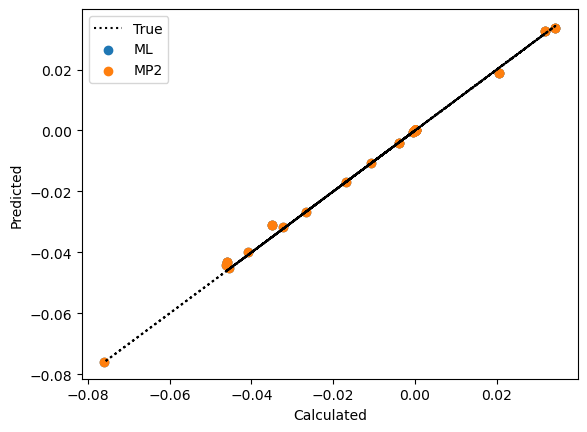

In [15]:
plt.plot(A.t2.flatten(),A.t2.flatten(),'k:',label='True')
plt.scatter(A.t2.flatten(),y_pred.flatten(),label='ML')
plt.scatter(A.t2.flatten(),A.t2start.flatten(),label='MP2')
plt.ylabel("Predicted")
plt.xlabel("Calculated")
plt.legend()
plt.show()

In [16]:
mean_absolute_error(A.t2.flatten(),y_pred.flatten()), r2_score(A.t2.flatten(),y_pred.flatten())

(0.0003658595235955777, 0.9977312817464397)

In [17]:
# Normal initialization
A.t1 = np.zeros((A.t1.shape))
# ML t2 amplitudes here
A.t2 = MP2T2
MP2E = A.compute_energy(iterate=False)

# Final energy
CCSDE = A.compute_energy()

# Calculation history
normalHistory = A.history


CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034836139854761   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132517044526   dE = -9.29638E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047020722545799   dE = -2.88821E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569824824988   dE = -1.54910E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048684428060897   dE = -1.14603E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691808563344   dE = -7.38050E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048689690477998   dE =  2.11809E-06   DIIS = 5
CCSD Iteration   7: CCSD correlation = -0.048690030584004   dE = -3.40106E-07   DIIS = 6
CCSD Iteration   8: CCSD correlation = -0.048689929937105   dE =  1.00647E-07   DI

In [18]:
check=True

if check==True:
    A.t1 = np.random.rand(*A.t1.shape)
    A.t2 = np.random.rand(*A.t2.shape)

A.compute_energy()

rdmHistory = A.history


CCSD Iteration   0: CCSD correlation = 0.354780092691228   dE = -3.54780E-01   MP2
CCSD Iteration   1: CCSD correlation = 0.054015639970104   dE = -3.00764E-01   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.006984348519018   dE = -6.10000E-02   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.035645224992361   dE = -2.86609E-02   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.042579834038529   dE = -6.93461E-03   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048315640723933   dE = -5.73581E-03   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048944966442249   dE = -6.29326E-04   DIIS = 5
CCSD Iteration   7: CCSD correlation = -0.048801478575582   dE =  1.43488E-04   DIIS = 6
CCSD Iteration   8: CCSD correlation = -0.048681692725596   dE =  1.19786E-04   DIIS = 7
CCSD Iteration   9: CCSD correlation = -0.048687722932061   dE = -6.03021E-06   DIIS = 7
CCSD Iteration  10: CCSD correlation = -0.048690635126259   dE = -2.91219E-06   DIIS = 7
CCSD Iteration  11: CCSD cor

In [19]:
check=True

if check==True:
    A.t1 = np.zeros(A.t1.shape)
    A.t2 = np.zeros(A.t2.shape)

A.compute_energy()

ZeroHistory = A.history


CCSD Iteration   0: CCSD correlation = 0.000000000000000   dE = -0.00000E+00   MP2
CCSD Iteration   1: CCSD correlation = -0.034836139854761   dE = -3.48361E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.044132517044522   dE = -9.29638E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048083253277615   dE = -3.95074E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048616020960860   dE = -5.32768E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048694254263370   dE = -7.82333E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048688449724239   dE =  5.80454E-06   DIIS = 5
CCSD Iteration   7: CCSD correlation = -0.048690366423278   dE = -1.91670E-06   DIIS = 6
CCSD Iteration   8: CCSD correlation = -0.048689759973172   dE =  6.06450E-07   DIIS = 7
CCSD Iteration   9: CCSD correlation = -0.048689950397433   dE = -1.90424E-07   DIIS = 7
CCSD Iteration  10: CCSD correlation = -0.048689945053484   dE =  5.34395E-09   DIIS = 7

CCSD has converged in 0.07

In [20]:
# Add the initial DDCC energy to the list
mlHistory.insert(0, (0,mlE_0))
# Add the MP2 energy to the list
normalHistory.insert(0, (0,MP2E))

In [21]:
print("Devations from the converged CCSD energies in mEh")
print(f"Abs MP2: {abs(MP2E-CCSDE) * 1e3:.4e} mEh")
print(f"Abs DDCC before iterations: {abs(mlE_0-CCSDE) * 1e3:.4e} mEh")
print(f"Abs DDCC after iterations: {abs(mlE - CCSDE) * 1e3:.4e} mEh")

Devations from the converged CCSD energies in mEh
Abs MP2: 1.3854e+01 mEh
Abs DDCC before iterations: 1.7866e-01 mEh
Abs DDCC after iterations: 2.1275e-06 mEh


In [22]:
MP2E-CCSDE

np.float64(0.013853804771259665)

In [23]:
mlHistory

[(0, np.float64(-0.04851128388433846)),
 (1, np.float64(-0.0478778003695168)),
 (2, np.float64(-0.04822127226536819)),
 (3, np.float64(-0.04854820195754635)),
 (4, np.float64(-0.04868807197220989)),
 (5, np.float64(-0.048692125799438046)),
 (6, np.float64(-0.04869020068900731)),
 (7, np.float64(-0.04868995194146101)),
 (8, np.float64(-0.048689941991969896))]

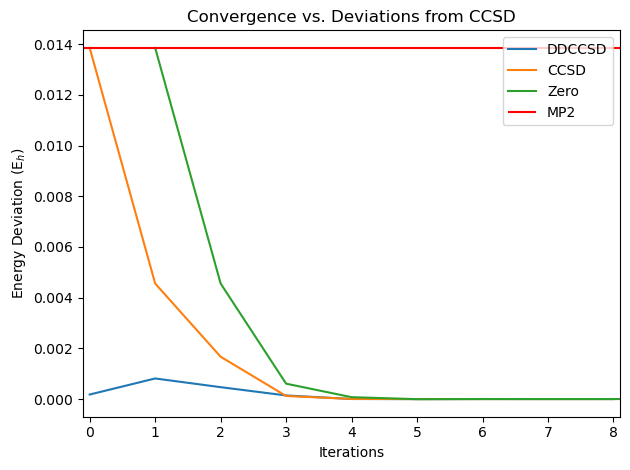

In [24]:
plt.plot(np.array(mlHistory)[:,0].T,np.array(mlHistory)[:,1].T-CCSDE,label='DDCCSD')
plt.plot(np.array(normalHistory)[:,0].T,np.array(normalHistory)[:,1].T-CCSDE,label='CCSD')
# plt.plot(np.array(rdmHistory)[:,0].T,np.array(rdmHistory)[:,1].T-CCSDE,label='Random')
plt.plot(np.array(ZeroHistory)[:,0].T,np.array(ZeroHistory)[:,1].T-CCSDE,label='Zero')
plt.hlines(MP2E-CCSDE,-1,50,color='r',label='MP2')
plt.xlim(0-0.1,len(normalHistory)-0.9)
# plt.ylim(-1e-3,9e-3)
plt.ylabel("Energy Deviation (E$_{h}$)")
plt.xlabel("Iterations")
plt.legend()
plt.title('Convergence vs. Deviations from CCSD')
plt.tight_layout()
plt.show()